In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from glob import glob

766640955


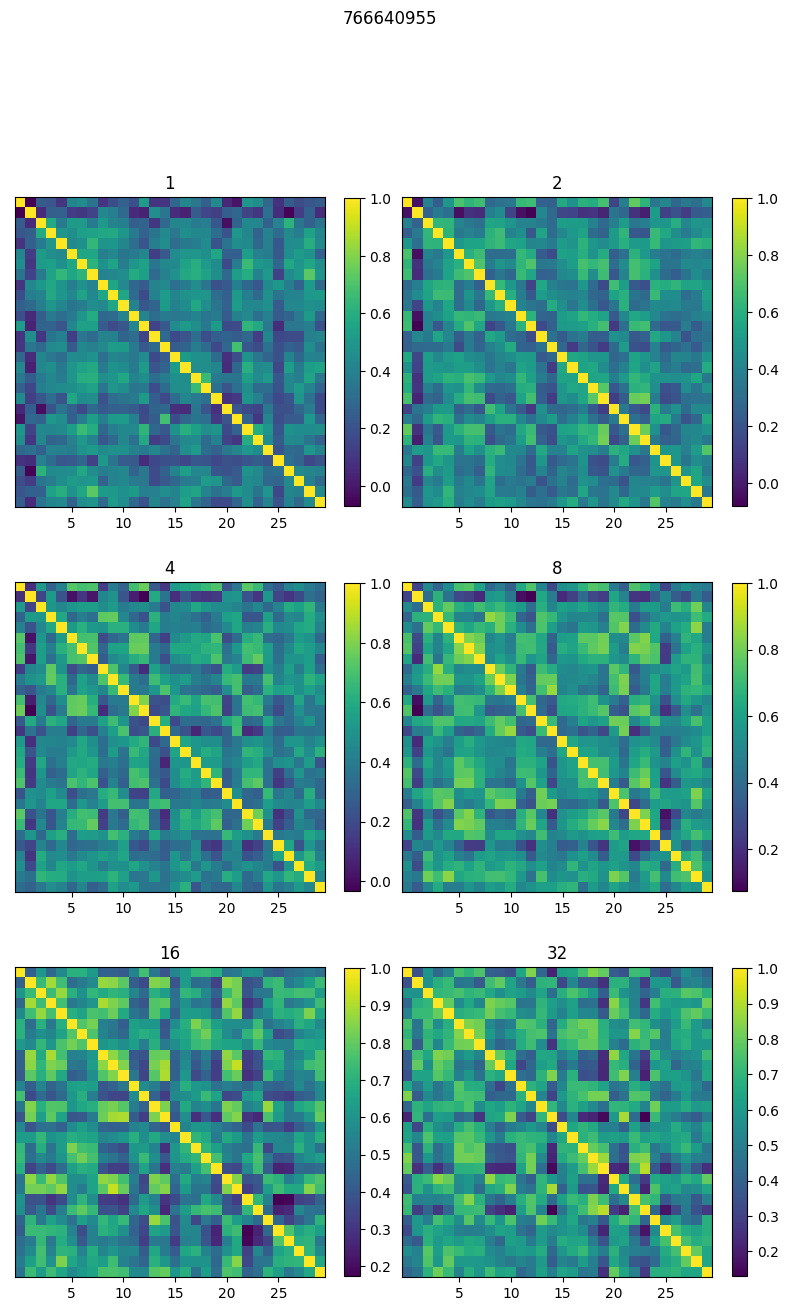

768515987


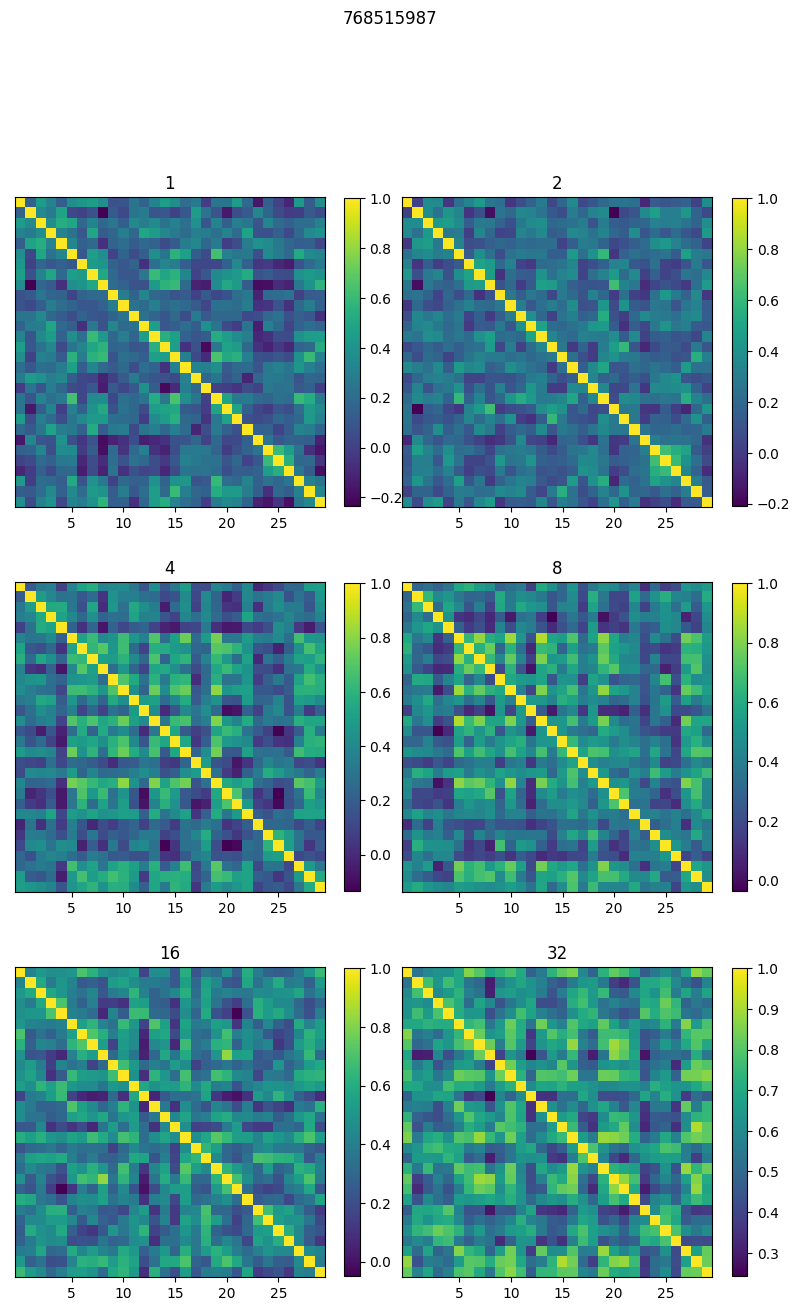

/home/tani/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/tani/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


771160300


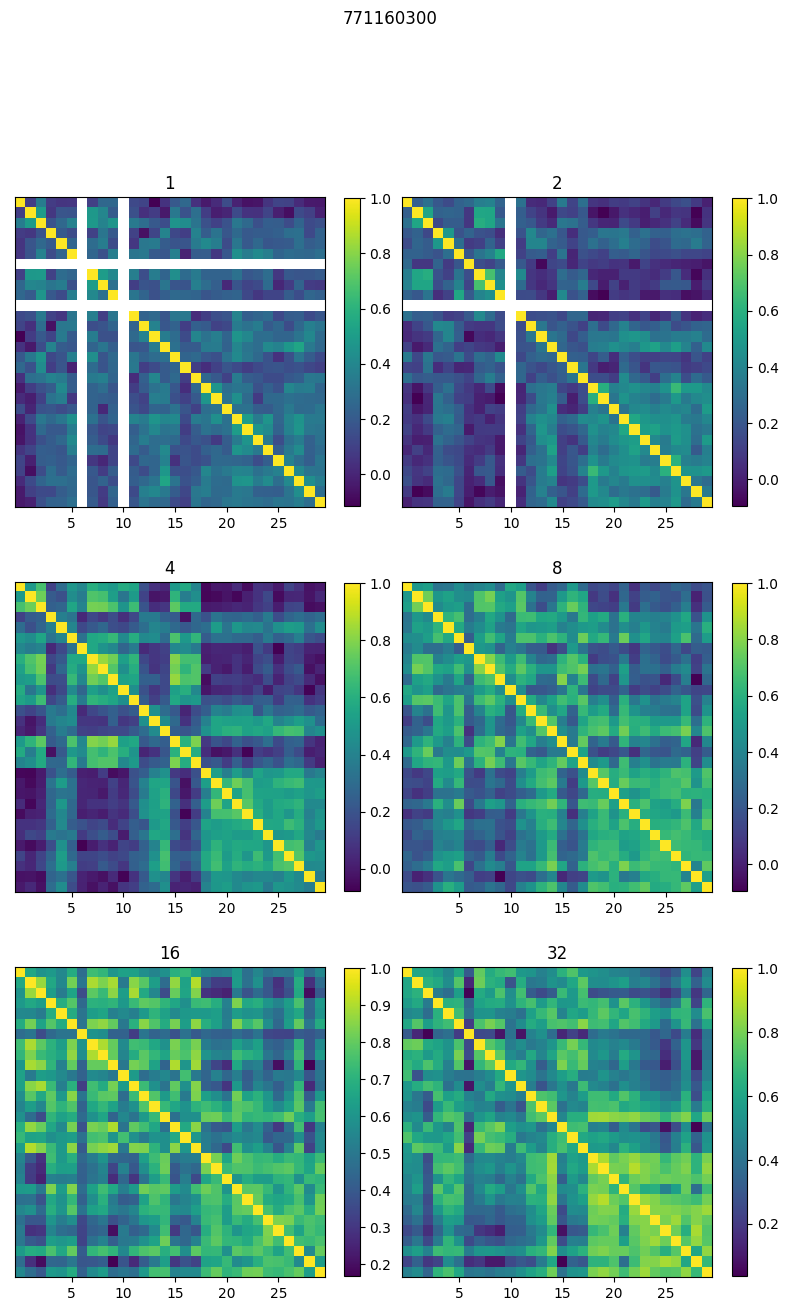

778240327


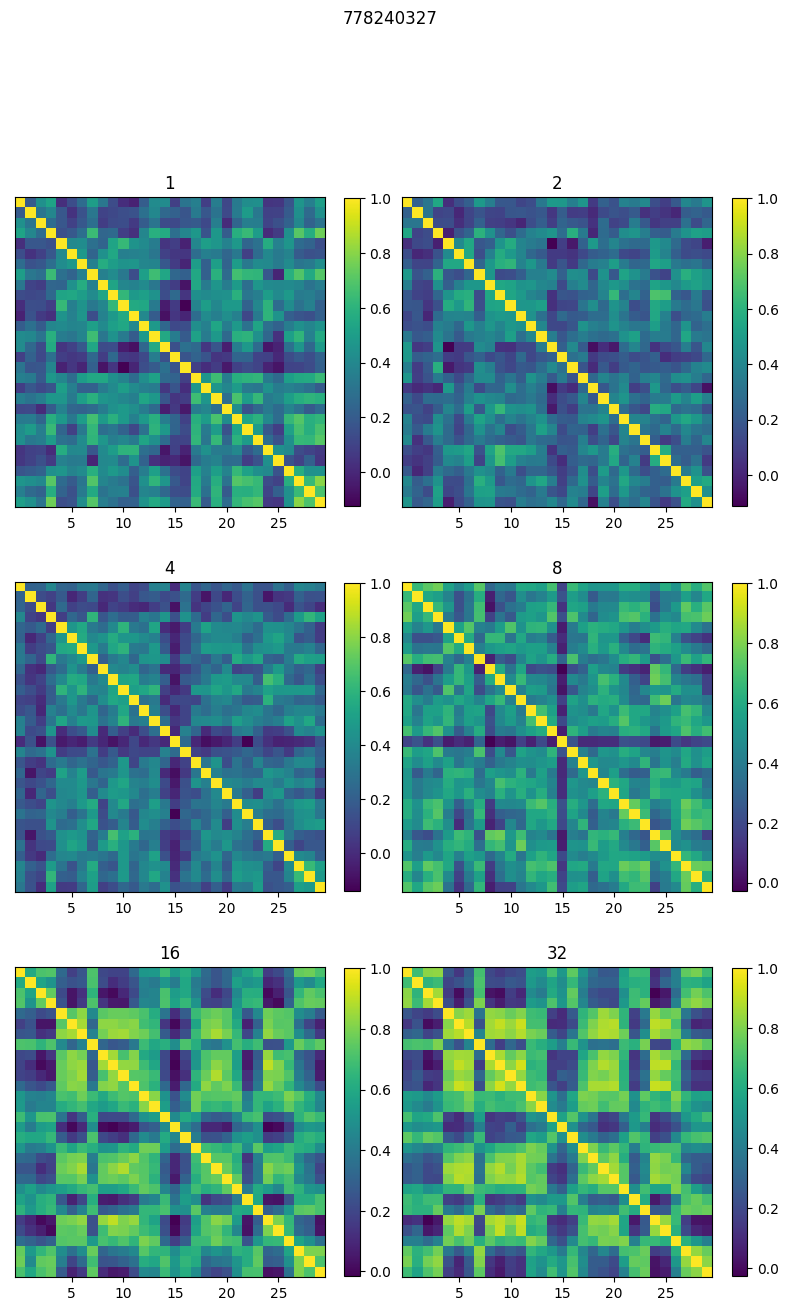

778998620


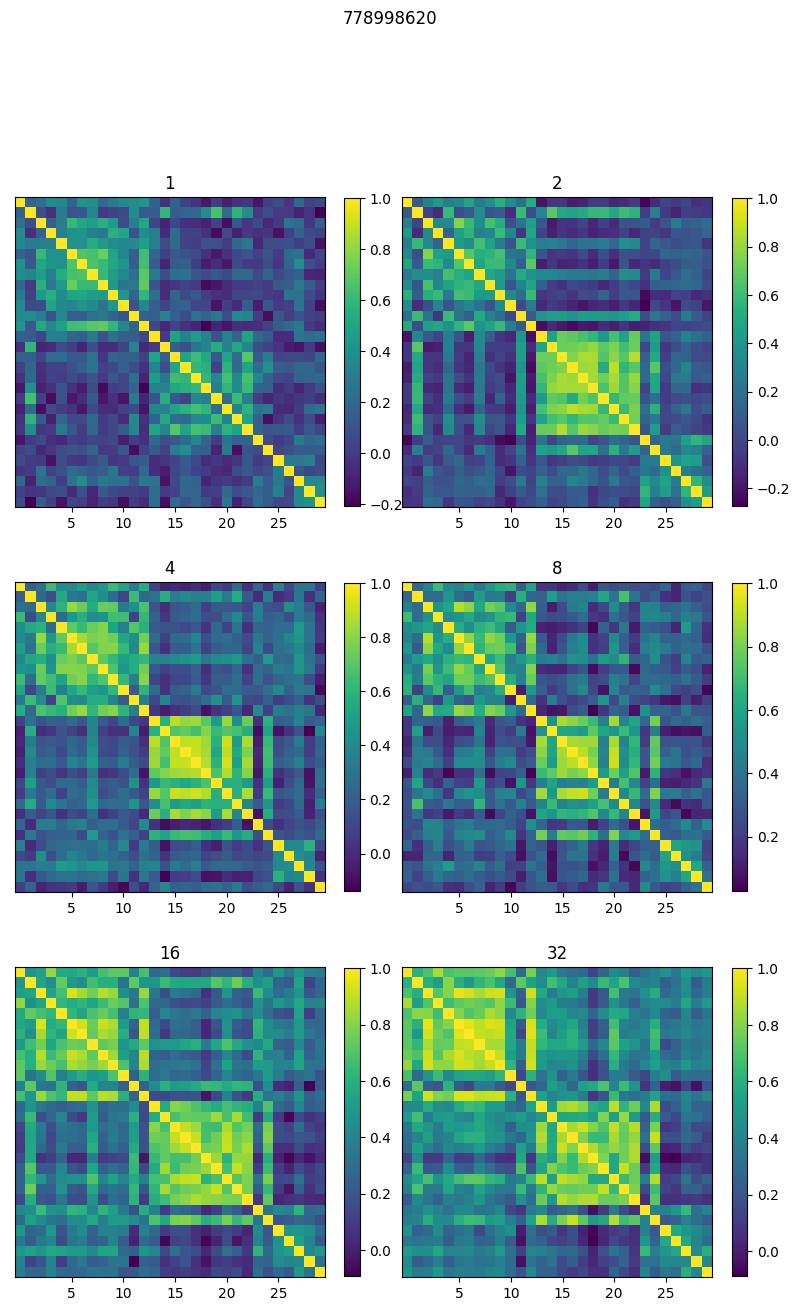

767871931


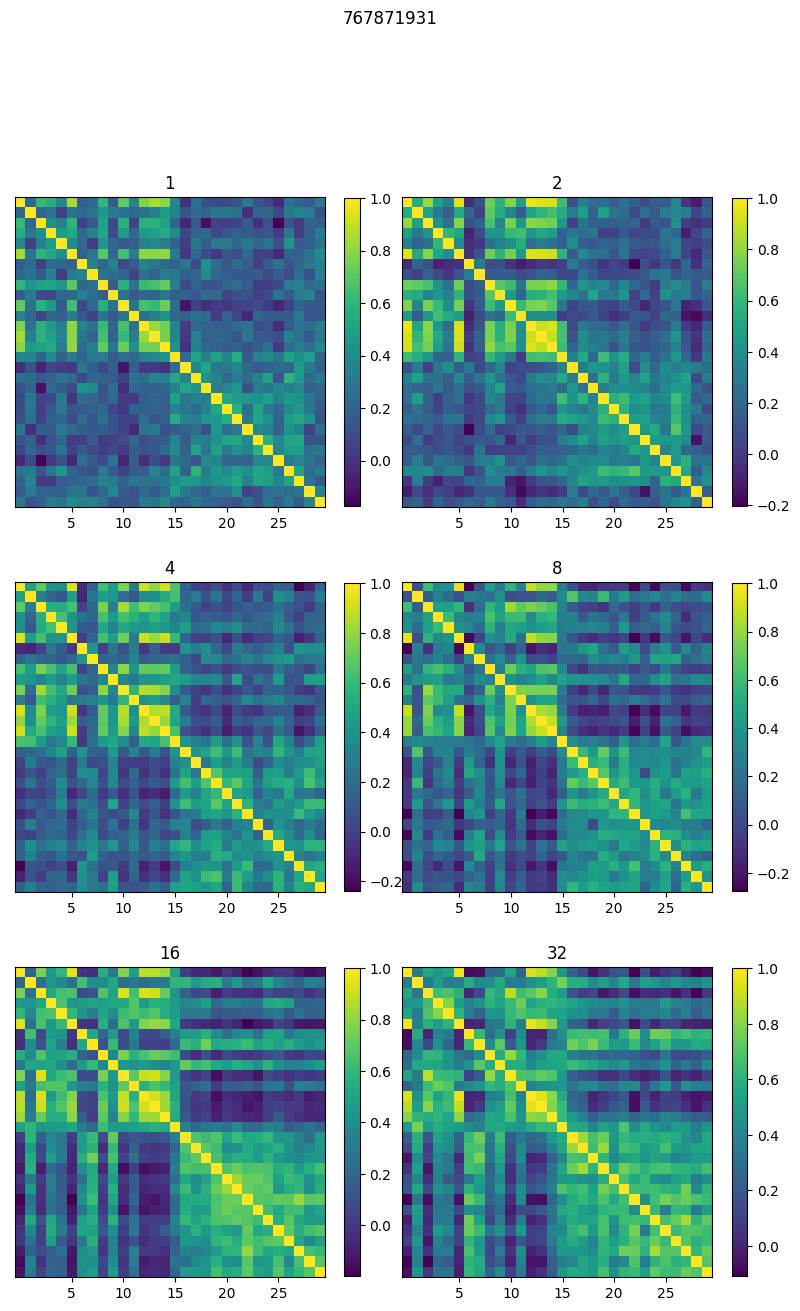

779839471


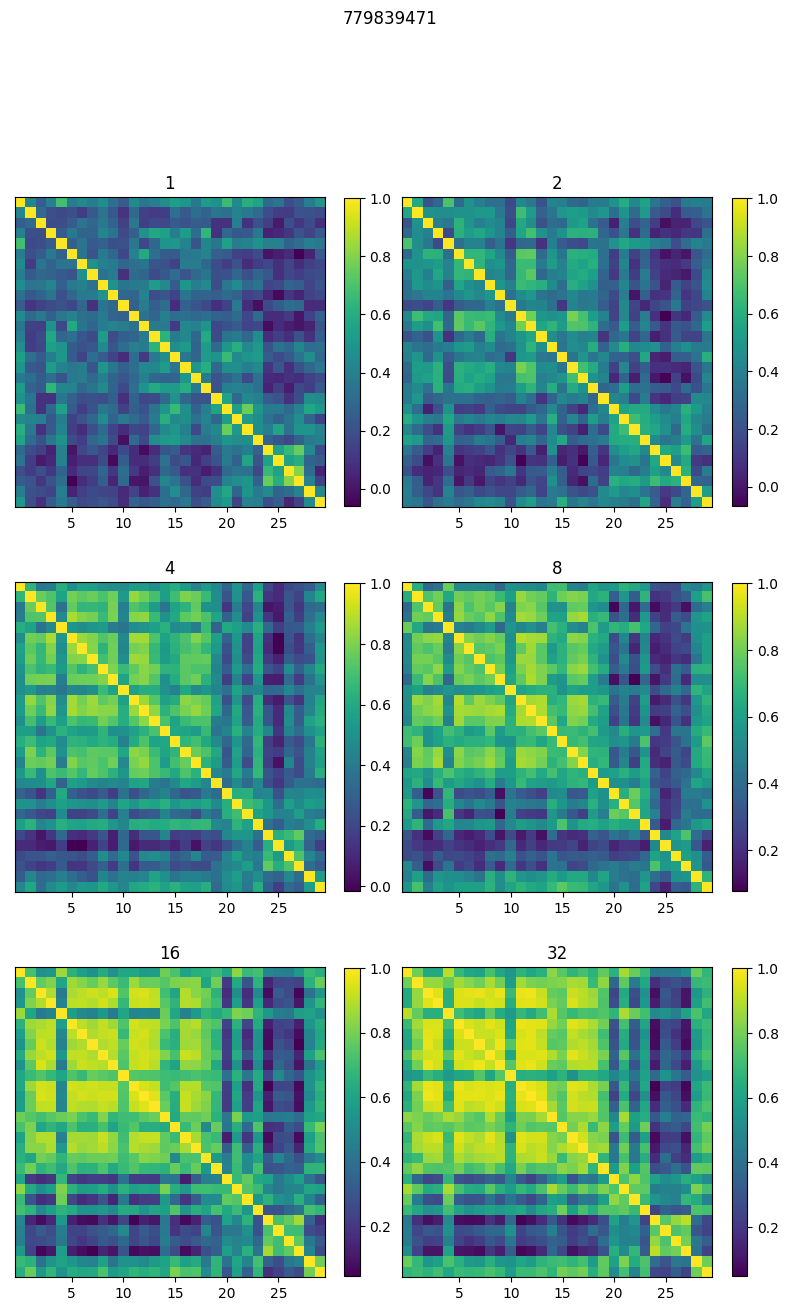

781842082


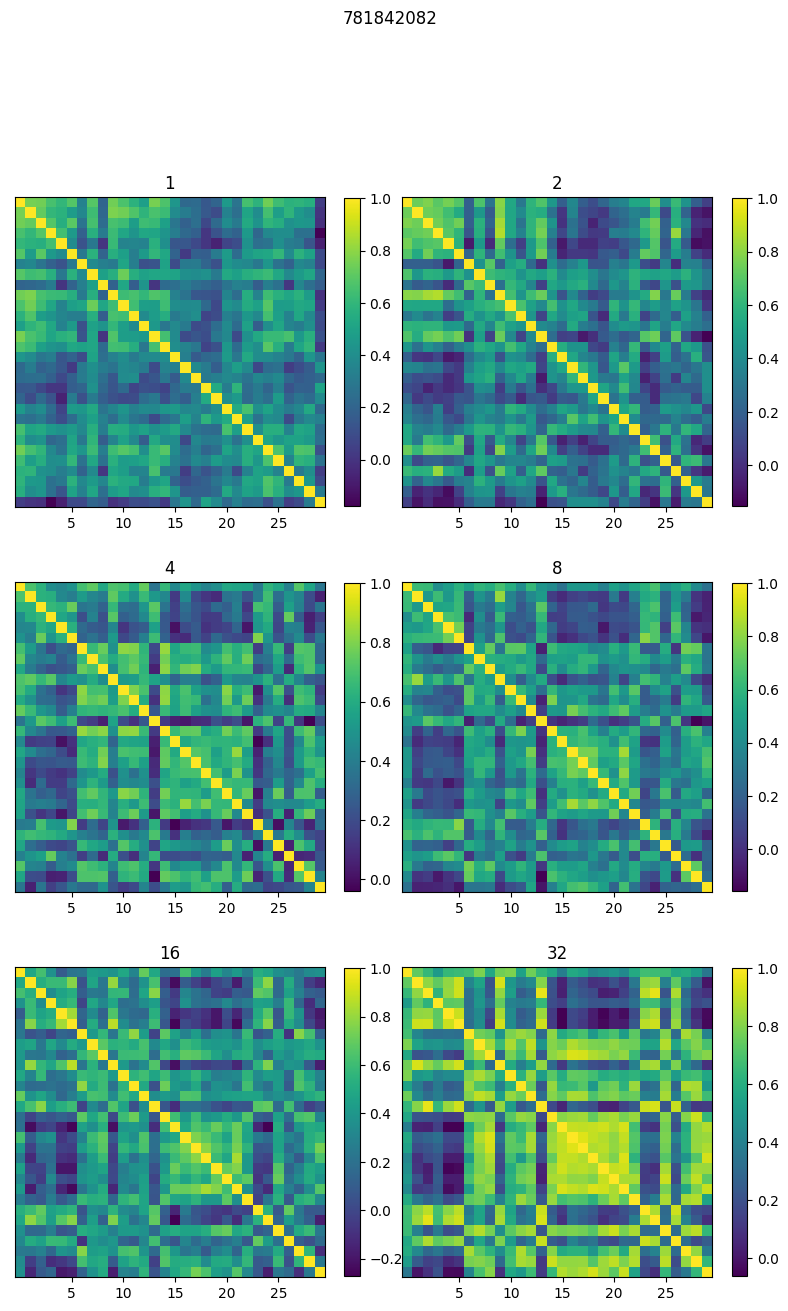

786091066


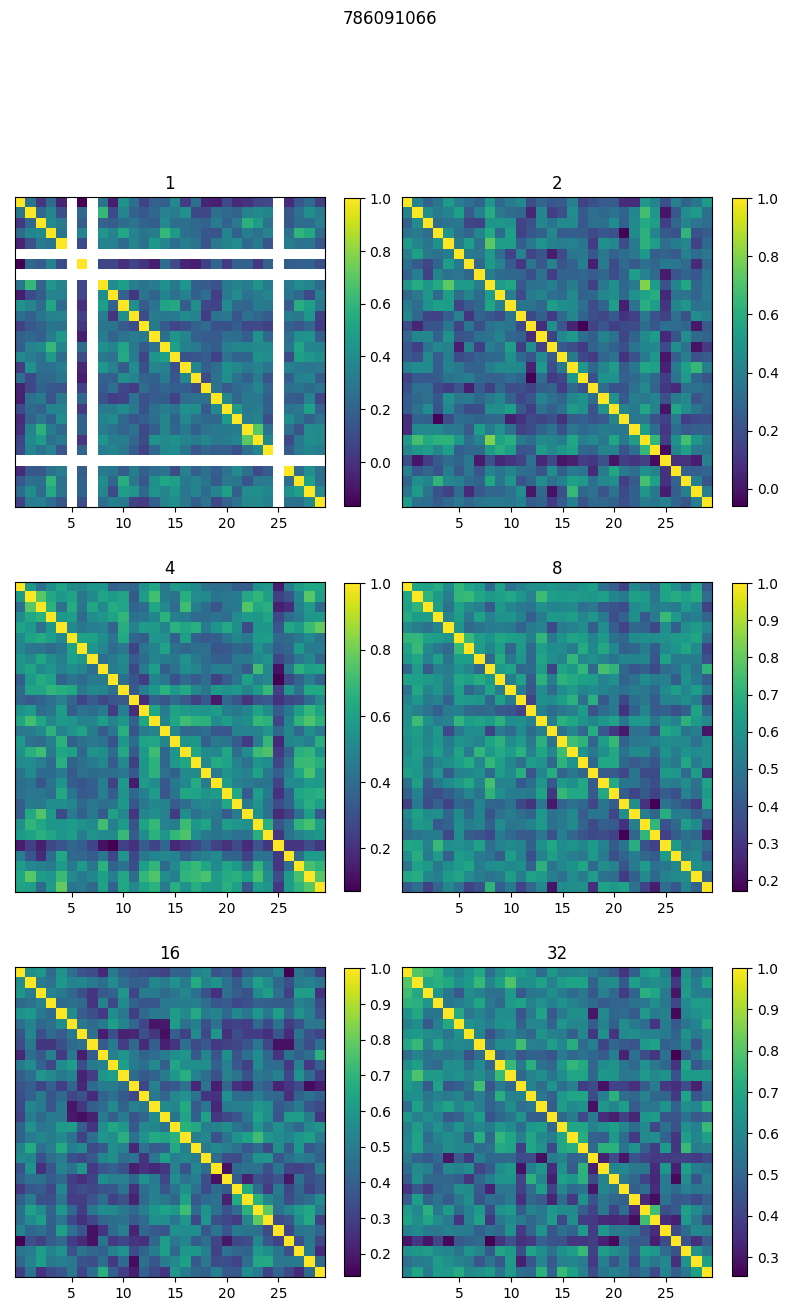

793224716


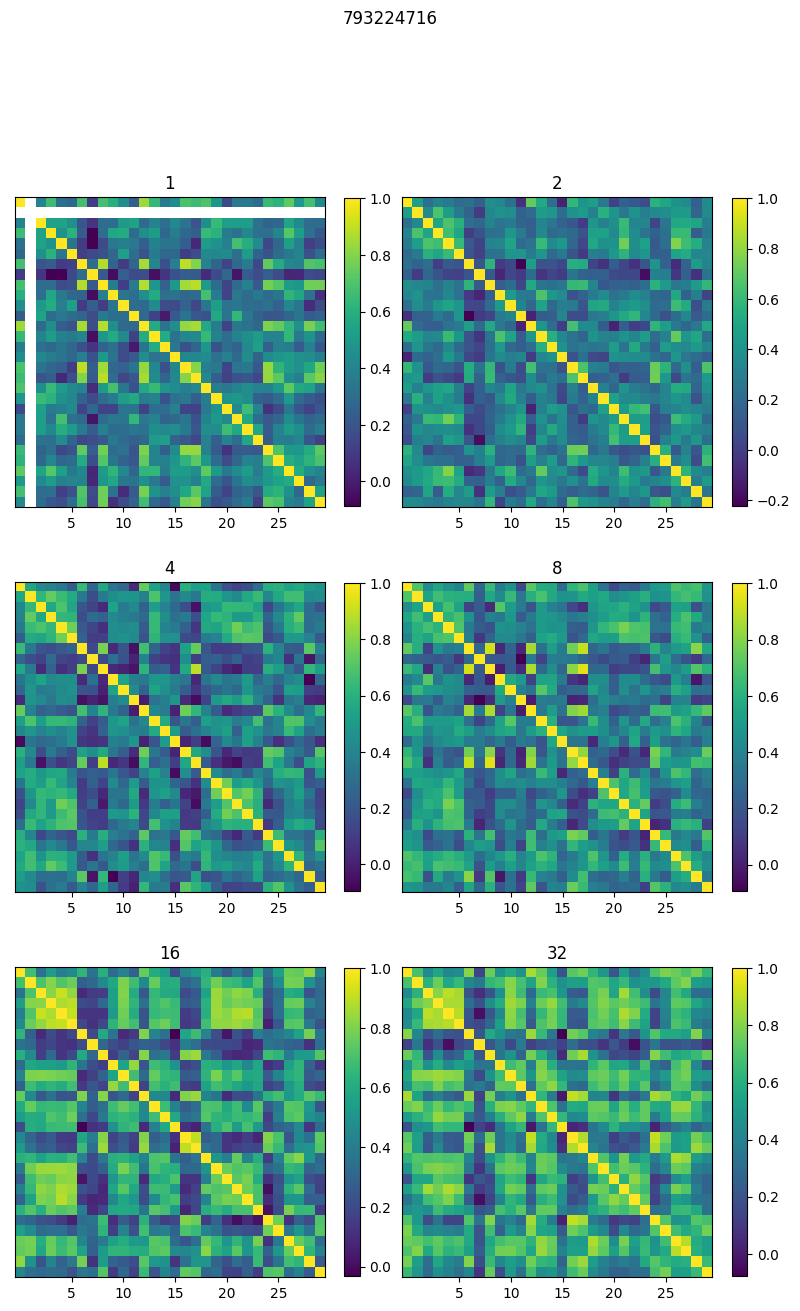

794812542


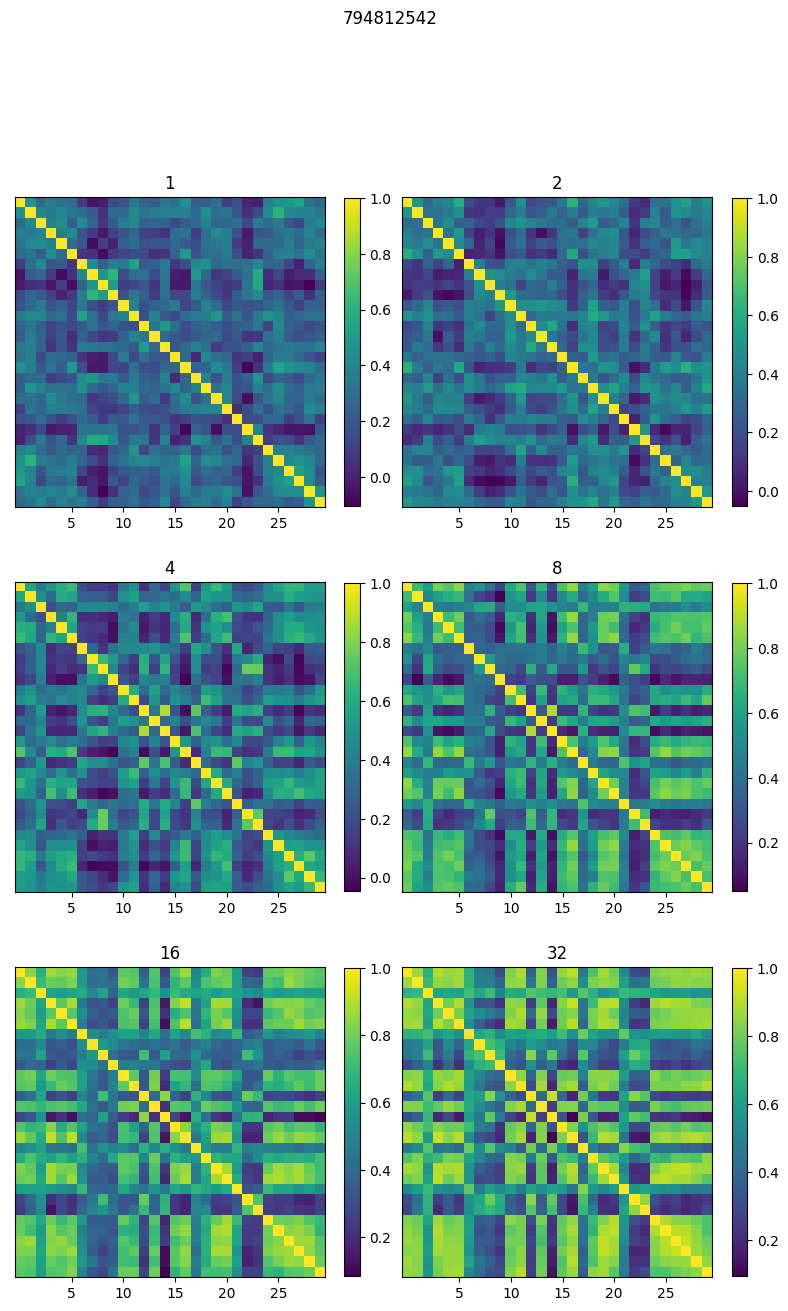

816200189


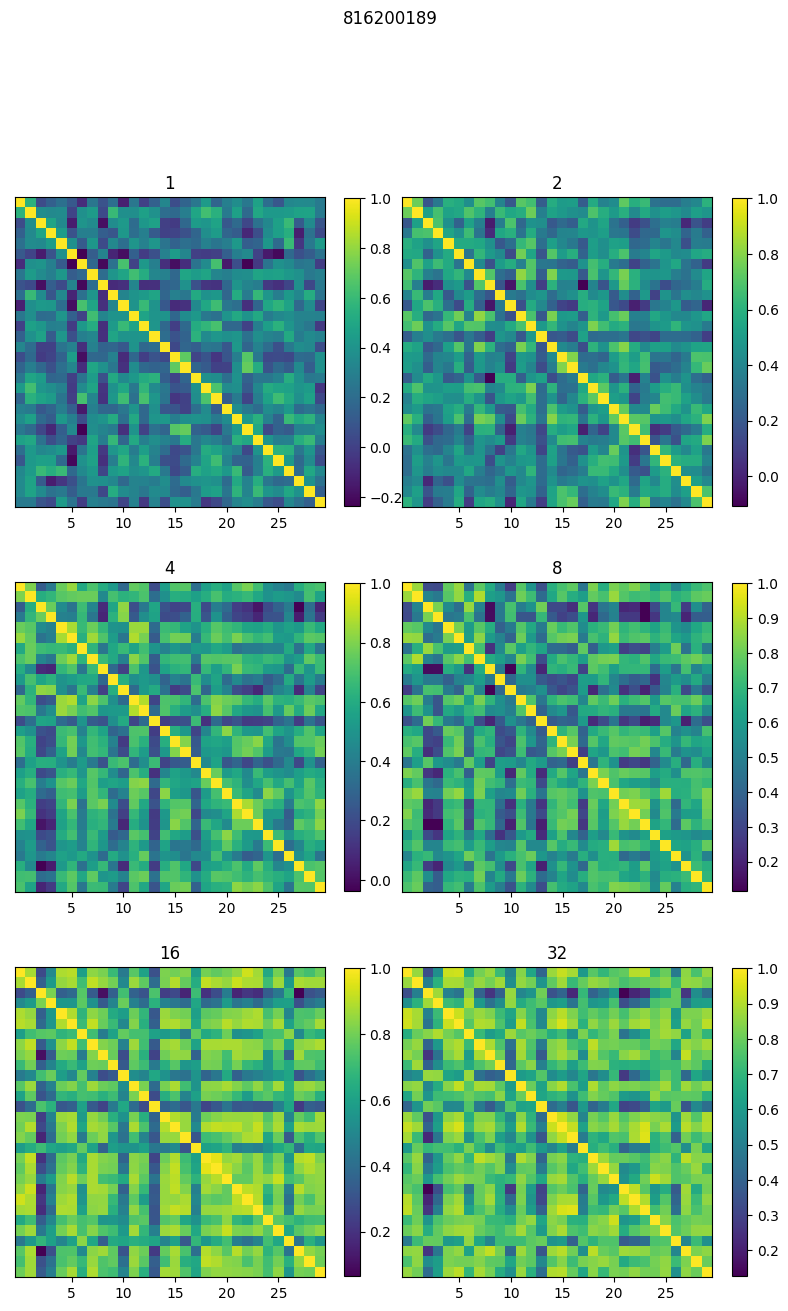

831882777


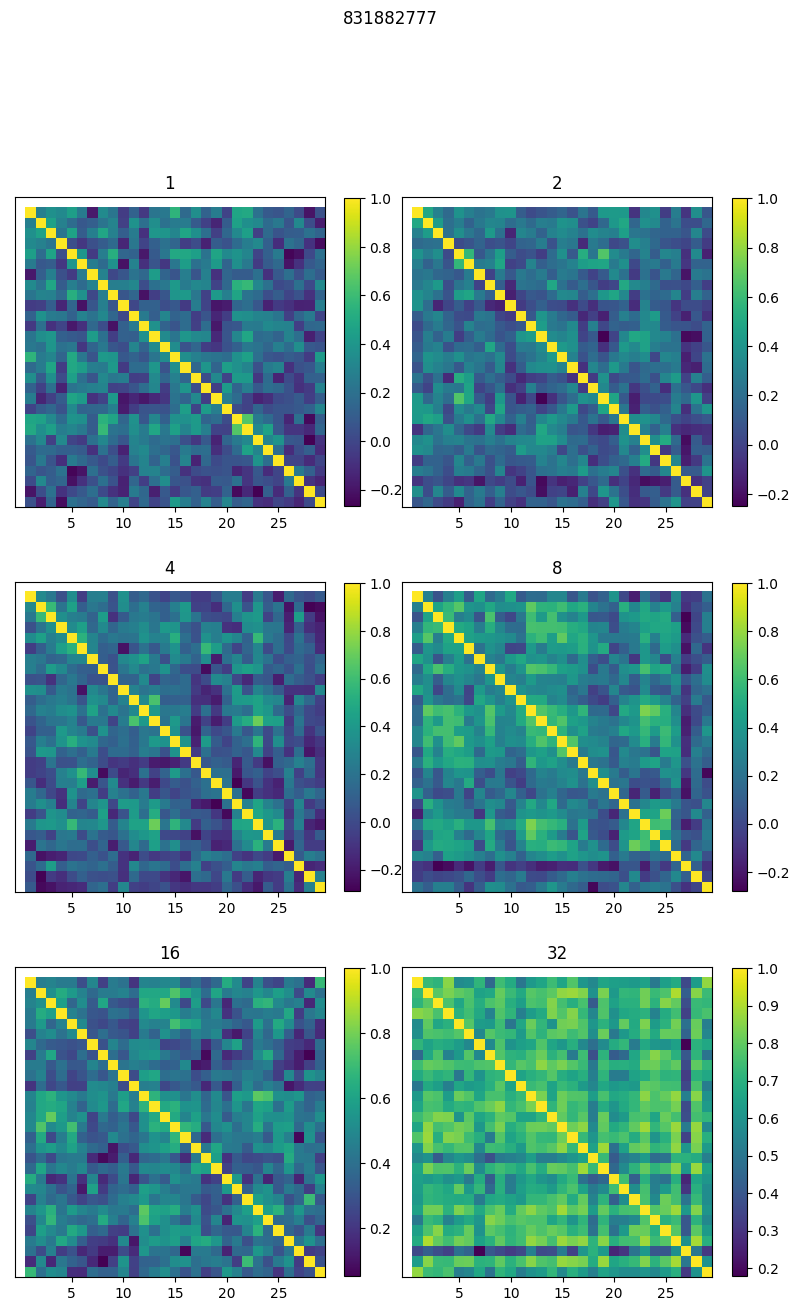

839068429


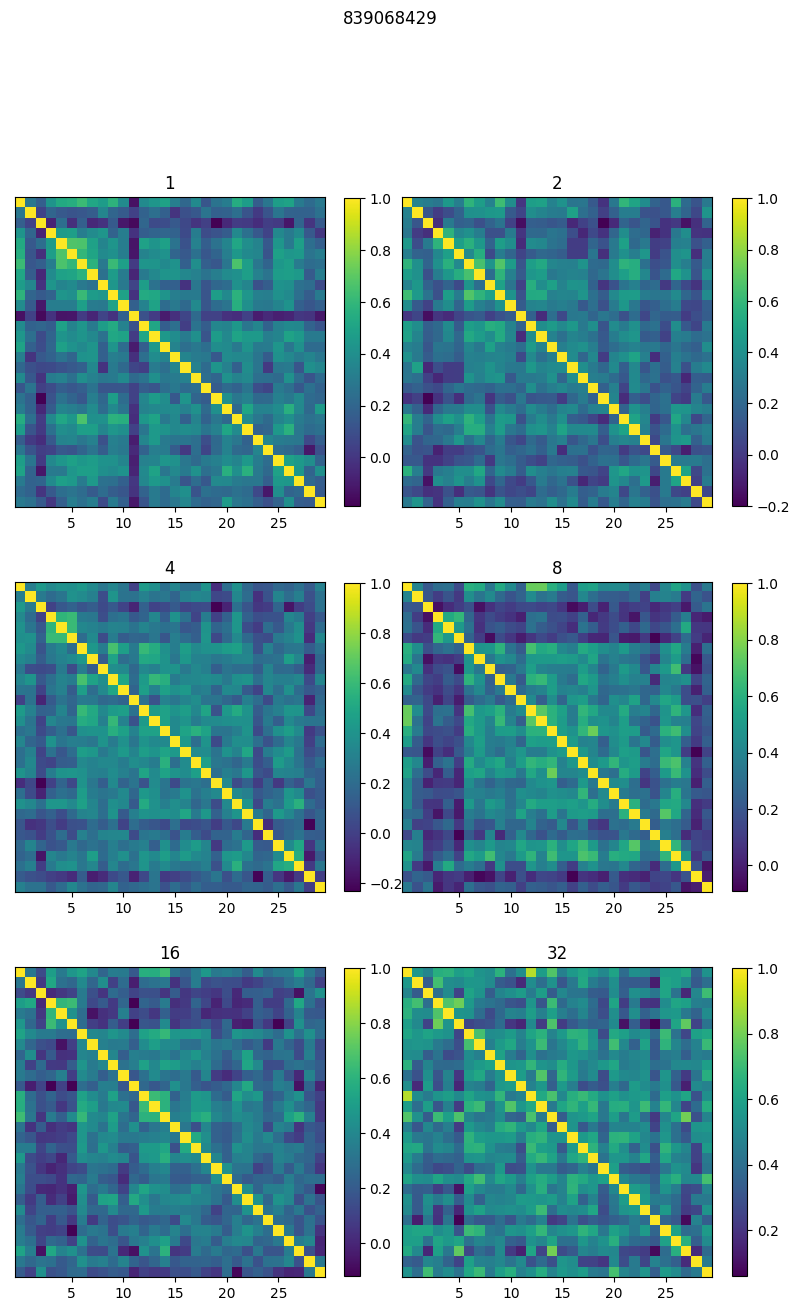

840012044


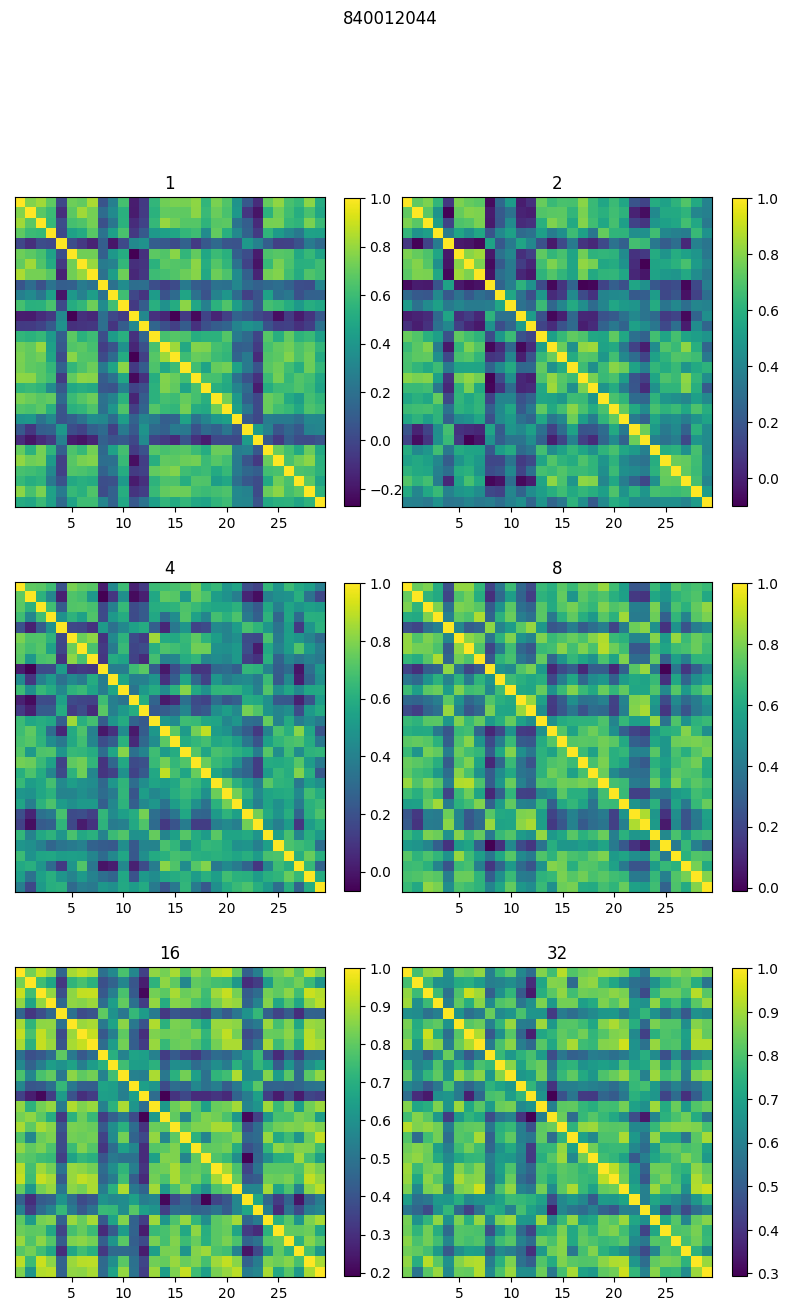

847657808


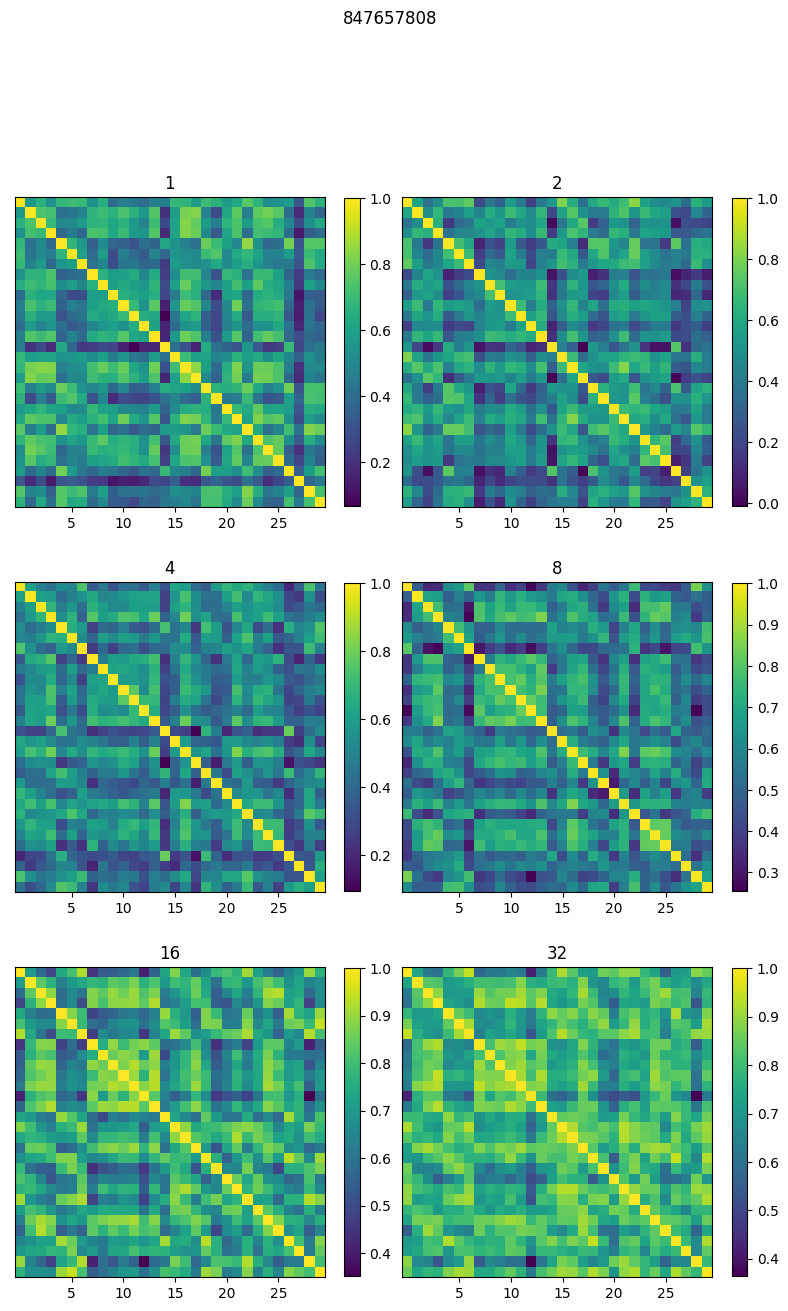

In [2]:
for filename in glob("../NonLinearityData/spiking/spiking_*_1000.mat"):
    mat = loadmat(filename)["spikes"]

    name = filename.split("_")[1]
    el_num = mat.shape[1]
    el_pair = int(el_num*(el_num-1)/2)

    corr1 = np.empty((30,el_pair,6))
    for i in np.arange(30):
        for j in range(6):
            corr1[i,:,j] = np.corrcoef(mat[60*i:60*(i+1),:,j], rowvar=False)[np.triu_indices(el_num,1)]
    
    corr2 = np.empty((30,30,6))
    for i in range(6):
        corr2[:,:,i] = np.corrcoef(corr1[:,:,i], rowvar=True)

    fig, ax = plt.subplots(3,2, figsize=(10,15))
    for i in range(6):
        plt.sca(ax[i//2,i%2])
        plt.imshow(corr2[:,:,i])
        plt.colorbar(shrink=0.8)
        plt.title(2**i)
        plt.xticks([5,10,15,20,25])
        plt.yticks([])
    plt.suptitle(name)
    print(name)
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

779839471


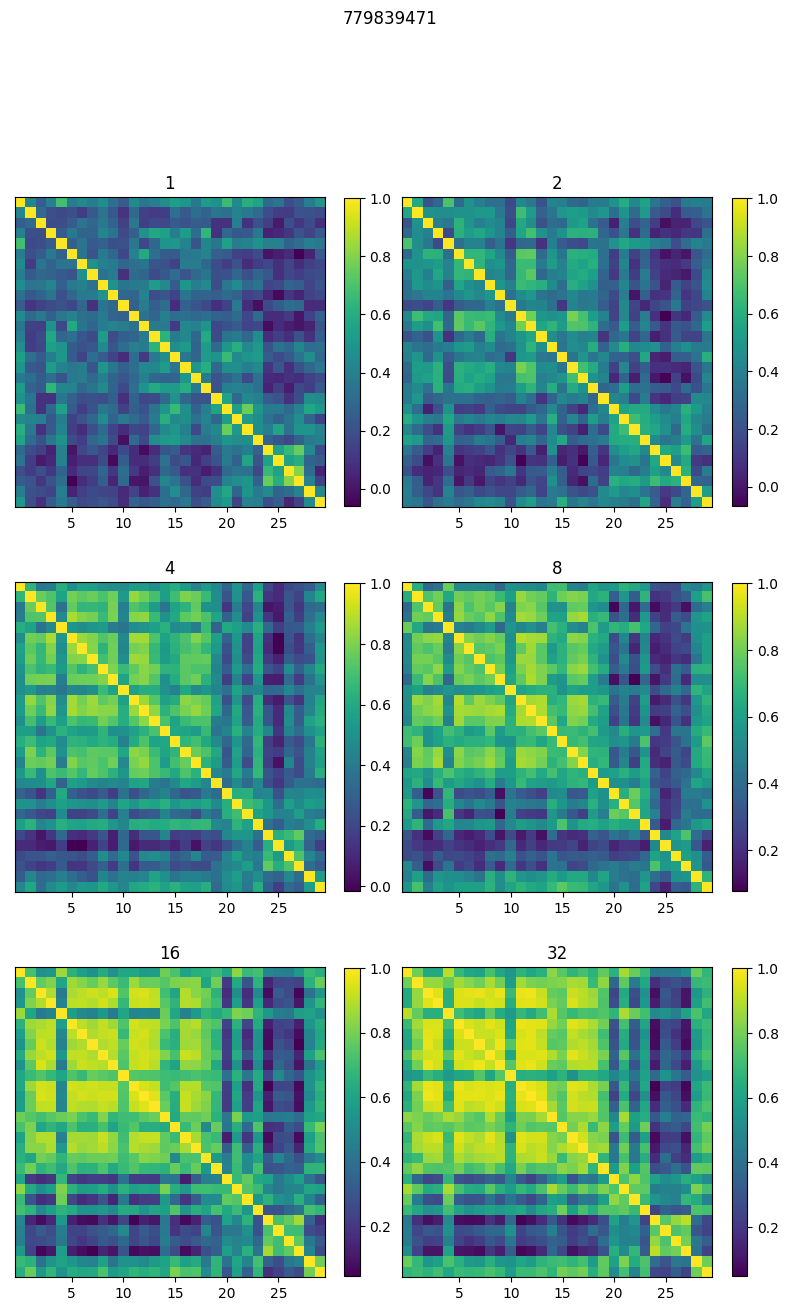

In [11]:
filename = "../NonLinearityData/spiking/spiking_779839471_1000.mat"
mat = loadmat(filename)["spikes"]

name = filename.split("_")[1]
el_num = mat.shape[1]
el_pair = int(el_num*(el_num-1)/2)

corr1 = np.empty((30,el_pair,6))
for i in np.arange(30):
    for j in range(6):
        corr1[i,:,j] = np.corrcoef(mat[60*i:60*(i+1),:,j], rowvar=False)[np.triu_indices(el_num,1)]

corr2 = np.empty((30,30,6))
for i in range(6):
    corr2[:,:,i] = np.corrcoef(corr1[:,:,i], rowvar=True)

fig, ax = plt.subplots(3,2, figsize=(10,15))
for i in range(6):
    plt.sca(ax[i//2,i%2])
    plt.imshow(corr2[:,:,i])
    plt.colorbar(shrink=0.8)
    plt.title(2**i)
    plt.xticks([5,10,15,20,25])
    plt.yticks([])
plt.suptitle(name)
print(name)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [22]:
cmap = plt.cm.jet  # define the colormap
# extract all colors from the .jet map
cmaplist = [cmap(i) for i in range(cmap.N)]

# create the new map
cmap = mplcol.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)

array([2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2,
       2, 2, 1, 1, 1, 1, 5, 6], dtype=int32)

In [110]:
from mienc import Corrector
import seaborn as sns
import re
import json
import os

sns.set_theme("talk", "ticks")
closer = 847657808
tru_maps = []
gau_maps = []
cor_maps = []
for folder in sorted(glob(f"../NonLinearityResultsNew/spiking_{closer}_*")):
    timeWindow = int(re.findall(r"_(\d{4})_", folder)[0])
    bins = int(re.findall(r"_bin(\d+)", folder)[0])
    with open(f"{folder}/shape.json") as fp:
        samples, groups, sizes = json.load(fp)
    c = Corrector(bins,samples,200,50000,samples,folder,"cache",1,False,False,True,"config.ini",True)
    c.compute_correction()
    tru_maps.append(np.zeros((groups,groups,sizes)))
    gau_maps.append(np.zeros((groups,groups,sizes)))
    cor_maps.append(np.zeros((groups,groups,sizes)))
    for i in range(sizes):
        statsMI = np.load(os.path.join(folder,f"subject{i:02}_{bins}.npy"))
        pairs = statsMI.shape[0]
        statsMIcorrected = c.correct(statsMI)
        gaussMI = np.mean(statsMIcorrected[:,1:],1)
        tru_maps[-1][(*np.triu_indices(groups,1),np.full(statsMI.shape[0],i))] = statsMIcorrected[:,0]
        tru_maps[-1][:,:,i]+=tru_maps[-1][:,:,i].T
        np.fill_diagonal(tru_maps[-1][:,:,i], np.inf)
        gau_maps[-1][(*np.triu_indices(groups,1),np.full(statsMI.shape[0],i))] = gaussMI[:]
        gau_maps[-1][:,:,i]+=gau_maps[-1][:,:,i].T
        np.fill_diagonal(gau_maps[-1][:,:,i], np.inf)
        correlation = np.load(os.path.join(folder,f"subject{i:02}_{bins}_cor.npy"))
        cor_maps[-1][(*np.triu_indices(groups,1),np.full(statsMI.shape[0],i))] = correlation
        cor_maps[-1][:,:,i]+=cor_maps[-1][:,:,i].T+np.eye(groups)#0.9298734950321937*
    print(folder, timeWindow, statsMI.shape, samples, groups, sizes)
tru_maps = np.stack(tru_maps, -1)
gau_maps = np.stack(gau_maps, -1)
cor_maps = np.stack(cor_maps, -1)
mic_maps = -.5*np.log(1-cor_maps**2)
rnl_maps = 1-gau_maps/tru_maps

Loading correction for 14420 samples and 24 bins.
../NonLinearityResultsNew/spiking_847657808_0125_bin24 125 (105, 100) 14420 15 6
Loading correction for 7210 samples and 19 bins.
../NonLinearityResultsNew/spiking_847657808_0250_bin19 250 (105, 100) 7210 15 6
Loading correction for 3605 samples and 15 bins.
../NonLinearityResultsNew/spiking_847657808_0500_bin15 500 (105, 100) 3605 15 6
Loading correction for 1802 samples and 12 bins.
../NonLinearityResultsNew/spiking_847657808_1000_bin12 1000 (105, 100) 1802 15 6
Loading correction for 901 samples and 9 bins.
../NonLinearityResultsNew/spiking_847657808_2000_bin9 2000 (105, 100) 901 15 6
Loading correction for 450 samples and 7 bins.
../NonLinearityResultsNew/spiking_847657808_4000_bin7 4000 (105, 100) 450 15 6
Loading correction for 225 samples and 6 bins.
../NonLinearityResultsNew/spiking_847657808_8000_bin6 8000 (105, 100) 225 15 6


/tmp/ipykernel_7510/3920007125.py:40: RuntimeWarning: divide by zero encountered in log
  mic_maps = -.5*np.log(1-cor_maps**2)
/tmp/ipykernel_7510/3920007125.py:41: RuntimeWarning: divide by zero encountered in divide
  rnl_maps = 1-gau_maps/tru_maps
/tmp/ipykernel_7510/3920007125.py:41: RuntimeWarning: invalid value encountered in divide
  rnl_maps = 1-gau_maps/tru_maps


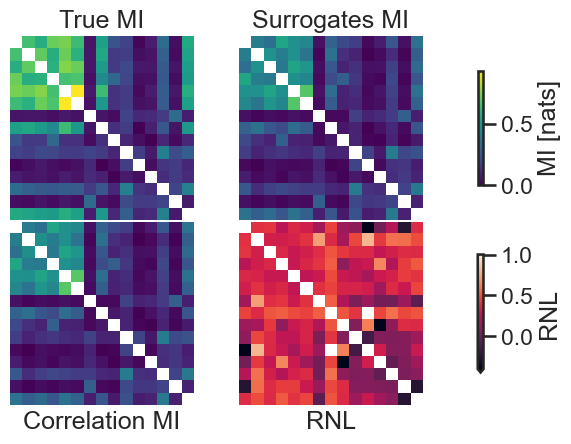

In [111]:
group_size = 5 # 0 = 1 unit, ..., 5 = 32 units
time_width = 5 # 0 = 125 ms, ..., 6 = 8 s 

cor_min = np.min(np.concatenate([a[np.isfinite(a)] for a in (tru_maps[:,:,group_size, time_width], gau_maps[:,:,group_size, time_width], mic_maps[:,:,group_size, time_width])]))
cor_max = np.max(np.concatenate([a[np.isfinite(a)] for a in (tru_maps[:,:,group_size, time_width], gau_maps[:,:,group_size, time_width], mic_maps[:,:,group_size, time_width])]))

fig, ax = plt.subplots(2,3,gridspec_kw={'width_ratios':[6,6,1]})

plt.sca(ax[0,0])
plt.imshow(tru_maps[:,:,group_size, time_width], vmin=cor_min, vmax=cor_max, cmap='viridis')
plt.title("True MI")
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)

plt.sca(ax[0,1])
plt.imshow(gau_maps[:,:,group_size, time_width], vmin=cor_min, vmax=cor_max, cmap='viridis')
plt.title("Surrogates MI")
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.colorbar(ax=ax[0,2], shrink=1.7,  label="MI [nats]")

plt.sca(ax[1,0])
plt.imshow(mic_maps[:,:,group_size, time_width], vmin=cor_min, vmax=cor_max, cmap='viridis')
plt.xlabel("Correlation MI")
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)

plt.sca(ax[1,1])
plt.imshow(rnl_maps[:,:,group_size, time_width], vmin=-0.4, vmax=1)
plt.xlabel("RNL")
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.colorbar(ax=ax[1,2], shrink=1.7, extend="min",extendfrac=0.03,  label="RNL")



plt.sca(ax[0,2])
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.sca(ax[1,2])
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.subplots_adjust(hspace=0.01, wspace=-0.0)
plt.show()

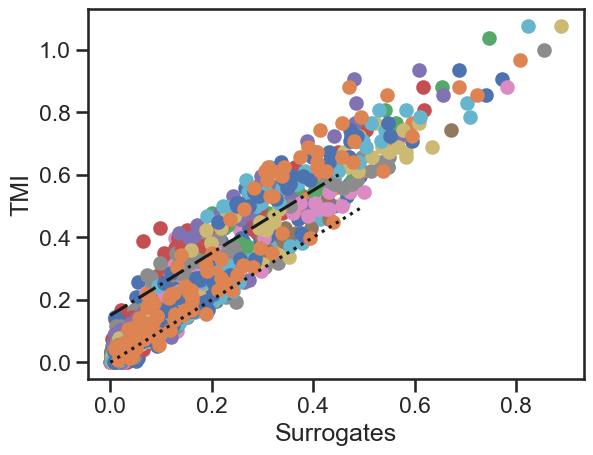

In [112]:
group_size = 5 # 0 = 1 unit, ..., 5 = 32 units
time_width = 5 # 0 = 125 ms, ..., 6 = 8 s 

for group_size in range(6):
    for time_width in range(7):
        plt.scatter(gau_maps[:,:,group_size, time_width][np.triu_indices(groups,1)],tru_maps[:,:,group_size, time_width][np.triu_indices(groups,1)])
plt.plot([0,0.5],[0,0.5], ":k")
plt.plot([0,0.45],[0.15,0.6], "-.k")
plt.xlabel("Surrogates")
plt.ylabel("TMI")
plt.show()

/tmp/ipykernel_7510/4219835228.py:5: RuntimeWarning: invalid value encountered in subtract
  interesting = (tru_maps[:,:,group_size, time_width]-gau_maps[:,:,group_size, time_width]) > 0.15


[3, 3, 5, 0, 0, 2, 0, 1, 2, 1, 4, 4, 0, 0, 2, 1, 0, 2, 1, 1, 4, 3, 3, 5, 0, 1, 2, 1, 7] [4, 7, 7, 2, 5, 5, 14, 3, 14, 12, 5, 14, 1, 7, 4, 2, 4, 7, 5, 14, 7, 5, 14, 14, 3, 4, 3, 7, 14]


/tmp/ipykernel_7510/4219835228.py:27: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show()
/tmp/ipykernel_7510/4219835228.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


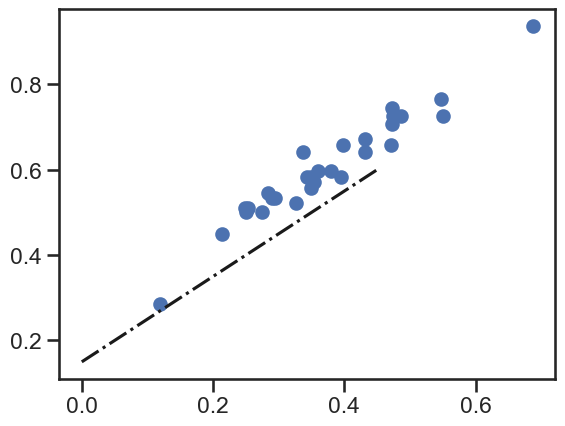

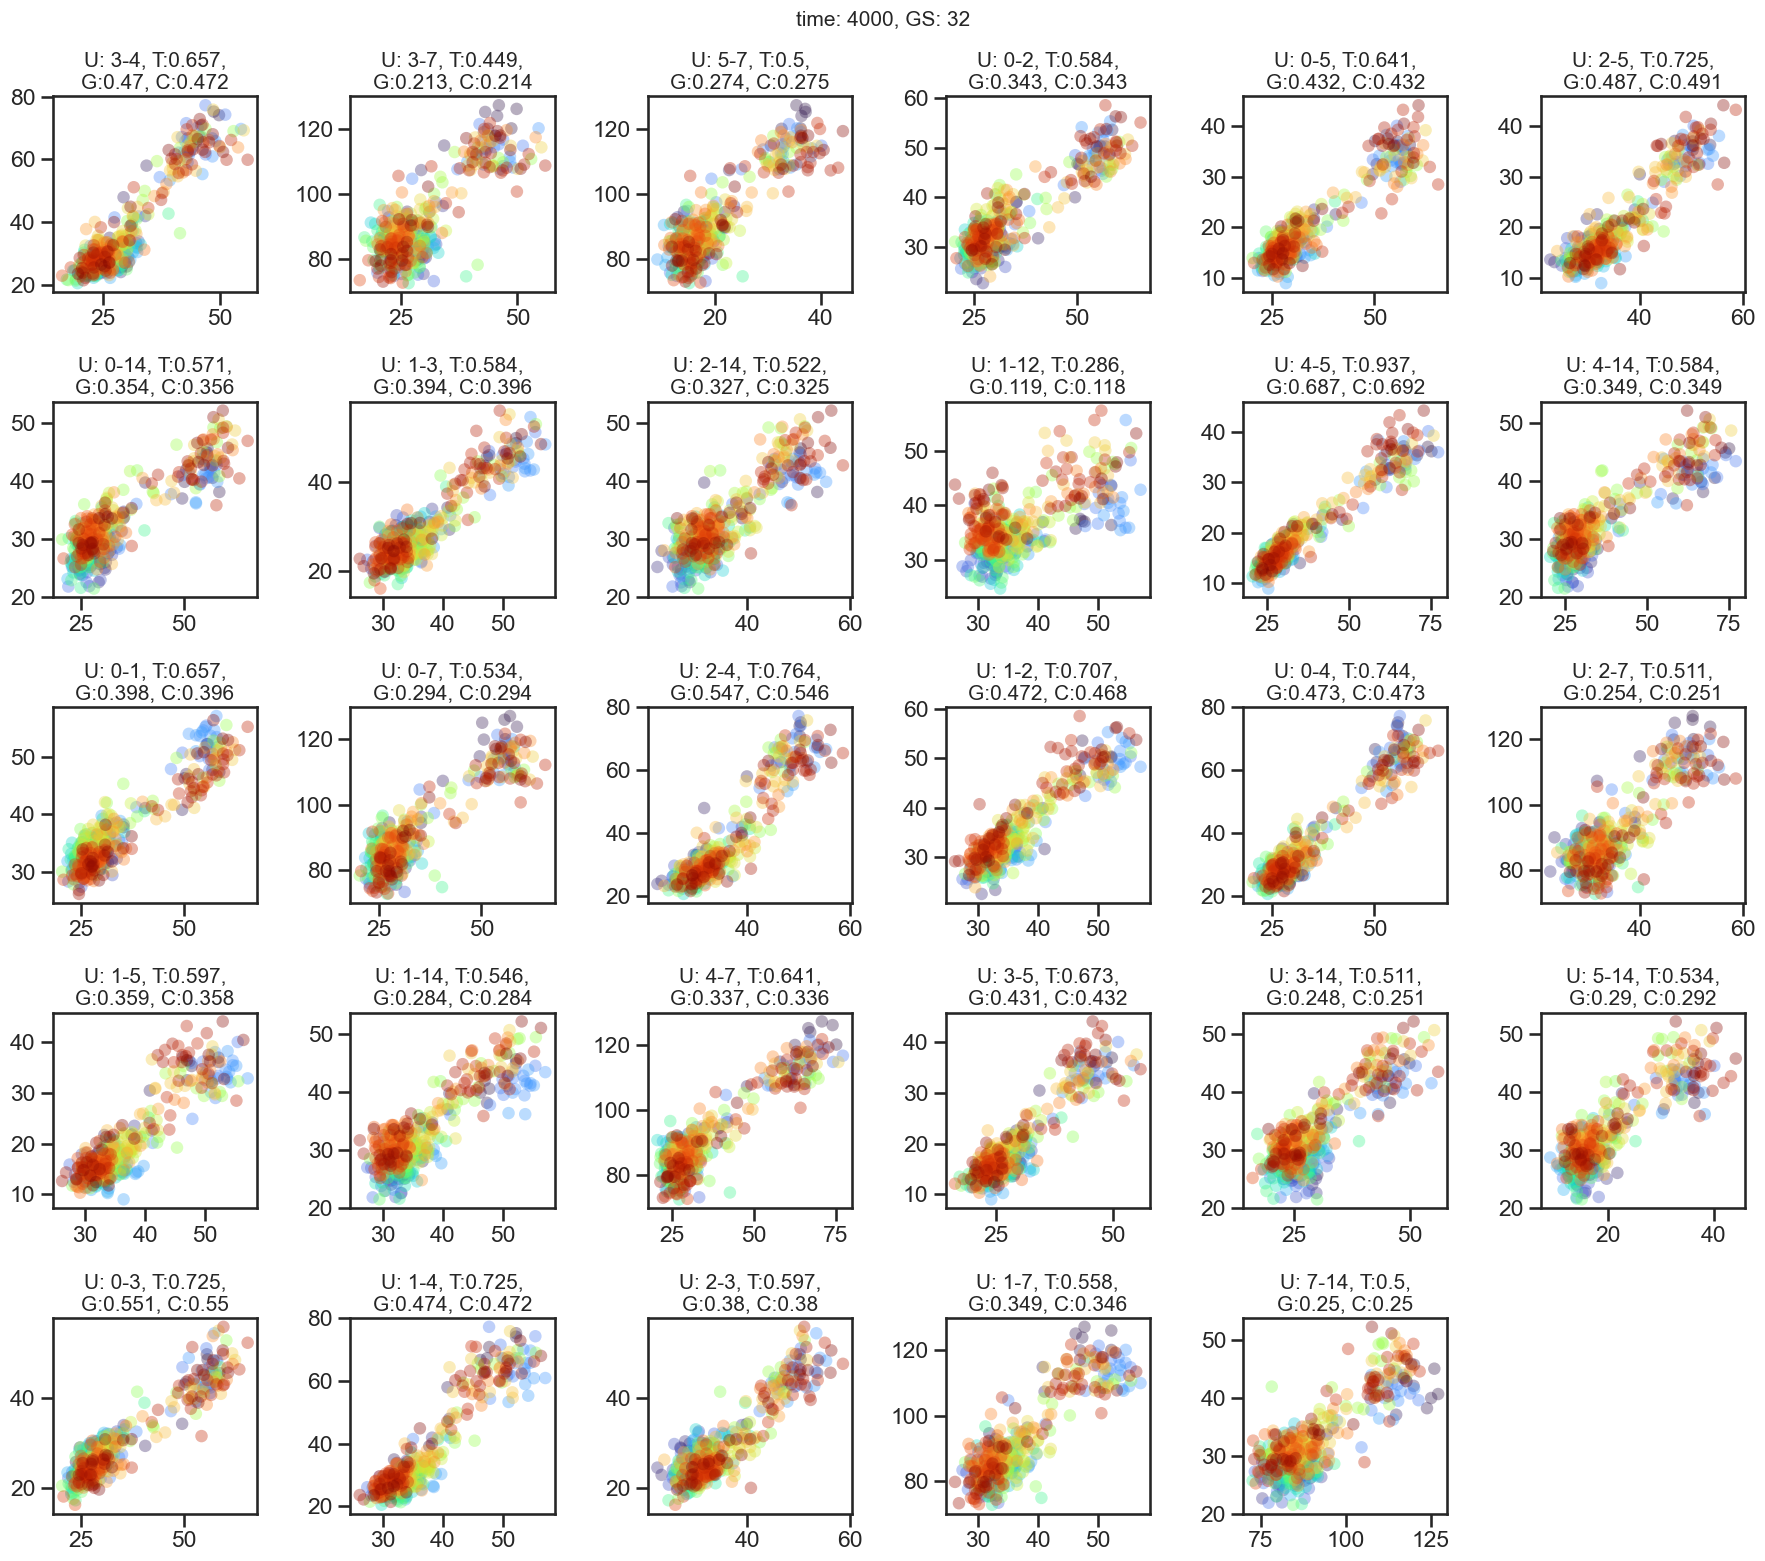

In [113]:
from scipy.io import loadmat
fig, ax = plt.subplots()
for group_size in [5]:#range(6):
    for time_width in [5]:#range(7):
        interesting = (tru_maps[:,:,group_size, time_width]-gau_maps[:,:,group_size, time_width]) > 0.15
        if interesting.any():
            i, j = np.where(interesting)
            pairs = {tuple(np.sort([a,b])) for a, b in zip(i,j)}
            I = []
            J = []
            mat = loadmat(f"../NonLinearityData/spiking/spiking_{closer}_{int(125*2**time_width):04}.mat")["spikes"]
            cols = np.sqrt(len(pairs))
            cols = int(cols)+1 if int(cols)!=cols else int(cols)
            rows = len(pairs)/cols
            rows = int(rows)+1 if int(rows)!=rows else int(rows)
            fig2, axes = plt.subplots(rows, cols, squeeze=False, figsize=(3*cols, 3*rows+1))
            for i, p in enumerate(pairs):
                a,b = p
                I.append(a)
                J.append(b)
                axes[i//cols, i%cols].scatter(mat[:,a,group_size], mat[:,b,group_size], c=np.arange(mat.shape[0]), cmap="turbo", alpha=0.35, edgecolors='none')
                axes[i//cols, i%cols].set_title(f"U: {a}-{b}, T:{tru_maps[a,b,group_size, time_width]:.3},\nG:{gau_maps[a,b,group_size, time_width]:.3}, C:{mic_maps[a,b,group_size, time_width]:.3}", fontsize="small")
            for j in range(i+1, cols*rows):
                axes[j//cols, j%cols].set_axis_off()
            fig2.suptitle(f"time: {int(125*2**time_width):04}, GS: {2**group_size}", fontsize="small")
            fig2.tight_layout()
            fig2.show()
            print(I, J)
            ax.scatter(gau_maps[I,J,group_size, time_width], tru_maps[I,J,group_size, time_width])
ax.plot([0,0.45],[0.15,0.6], "-.k")
fig.show()

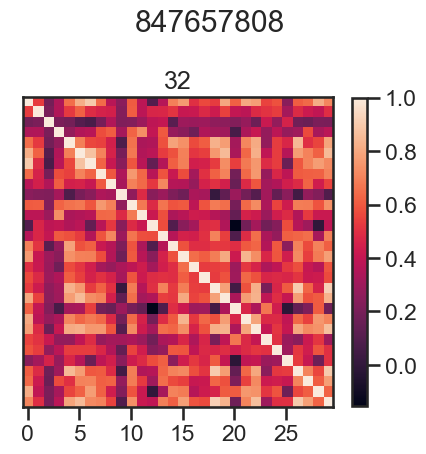

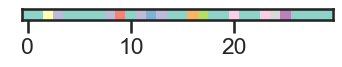

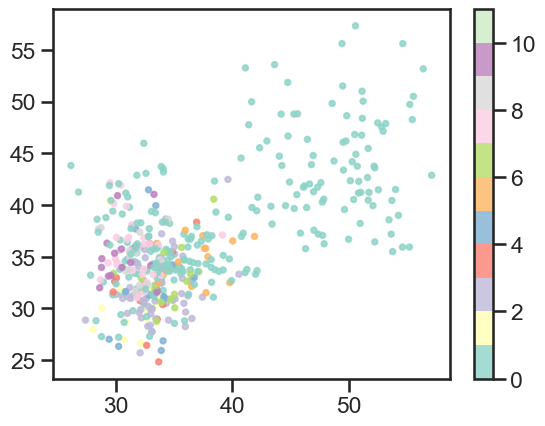

In [115]:
import matplotlib.colors as mplcol
filename = f"../NonLinearityData/spiking/spiking_{closer}_4000.mat"
TL=5
r1 = 1
r2 = 12
mat = loadmat(filename)["spikes"][:,:,TL]

name = filename.split("_")[1]
el_num = mat.shape[1]
el_pair = int(el_num*(el_num-1)/2)

corr1 = np.empty((30,el_pair))
for i in np.arange(30):
    corr1[i,:] = np.corrcoef(mat[15*i:15*(i+1),:], rowvar=False)[np.triu_indices(el_num,1)]

corr2 = np.empty((30,30))
corr2[:,:] = np.corrcoef(corr1[:,:], rowvar=True)

fig, ax = plt.subplots(1,1, figsize=(5,5))
plt.sca(ax)
plt.imshow(corr2[:,:])
plt.colorbar(shrink=0.8)
plt.title(2**TL)
plt.xticks([0, 5,10,15,20,25])
plt.yticks([])
plt.suptitle(name)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
corr_plt = (corr2[:,:] + corr2[:,:].T)/2                         # made symmetric
np.fill_diagonal(corr_plt, 1)                        # put 1 on the diagonal
dissimilarity = 1 - np.abs(corr_plt)
hierarchy = linkage(squareform(dissimilarity), method='average')
labels = fcluster(hierarchy, 0.4, criterion='distance')

n_class=len(set(labels))
new_lab = {}
top = 0
for l in labels:
    if l not in new_lab:
        new_lab[l] = top
        top += 1
        if top == n_class:
            break
labels[:] = [new_lab[i] for i in labels]
#labels[-1]=5
colors = np.repeat(labels,15)-1

# define the bins and normalize
bounds = np.linspace(0, n_class, n_class+1)
norm = mplcol.BoundaryNorm(bounds, n_class)#cmap.N)#plt.cm.Set3.N


plt.figure(figsize=(4,1))
plt.imshow(labels[np.newaxis, :]-1, cmap=plt.cm.Set3, norm=norm)
plt.yticks([])
plt.show()

plt.scatter(mat[:,r1],mat[:,r2], c=colors,cmap=plt.cm.Set3, norm=norm, alpha=0.8, s=15)#plt.cm.Set3, alpha=0.7)
plt.colorbar()
plt.show()